# Level 1 · Part 2 — Which segmentation can we trust?

The vendor ships one segmentation of this MERSCOPE section, but segmentation is a *choice*,
not ground truth. Here we **re-segment the same ~0.6 mm window four ways** and ask a concrete question:
**how many of the measured transcripts does each method actually place inside a cell, and are those
cells clean?**

We reuse the cropping idiom from Part 1, run three segmenters with **Sopa's own primitives — every
parameter and patch step out in the open, no hidden helpers** — then compare all four segmentations on
two axes:

1. **How much signal is captured** — the fraction of transcripts assigned to a cell.
2. **How clean the cells are** — *negative-marker purity* (do cells co-express genes from
   mutually-exclusive lineages, i.e. did transcripts leak across boundaries?).

## 0. Setup

In [1]:
import os

# Cellpose reaches through torch, OpenCV, BLAS *and* numba, each of which will otherwise spawn a
# thread per core and thrash the node. We make every worker **single-threaded** (caps below, set
# BEFORE importing torch) and get our parallelism instead by running patches across **Dask worker
# processes** in section 2 -- the pattern Sopa itself uses on a cluster.
for _v in (
    "OMP_NUM_THREADS",
    "MKL_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMBA_NUM_THREADS",
):
    os.environ[_v] = "1"
N_WORKERS = int(os.environ.get("SLURM_CPUS_PER_TASK", "8"))  # one worker per allocated core

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

import spatialdata as sd
import spatialdata_plot  # noqa: F401  (registers the `.pl` plotting accessor)
import sopa
from spatialdata import get_extent
from spatialdata.models import Image2DModel
from spatialdata.transformations import get_transformation

import torch

torch.set_num_threads(1)
torch.set_num_interop_threads(1)
import cv2

cv2.setNumThreads(1)

import warnings

warnings.simplefilter("ignore")  # keep the teaching output readable (zarr/dask notices)
sc.settings.verbosity = 1

### Where does the data live — and where do *you* write?

The baseline section is **staged once, read-only, and shared** by everyone on the course — you never
write there. Your crop and its segmentations go in **your clone's git-ignored `data/` folder**, via
the project's `FilePaths` helper, so your outputs stay next to your analysis and never touch the
shared copy (or git). We also point at an independent lineage **reference** (used later, for purity).

In [2]:
from spatialbrain import FilePaths  # project path helper

# Staged, read-only, shared — NEVER write here.
SHARED_ZARR = (
    "/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/"
    "data/wang2025_merfish/processed/UCSF2018-003-MFG_baseline.zarr"
)
# Independent reference of the same tissue with broad lineage labels only (for the purity metric).
SHARED_REF = (
    "/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/"
    "data/wang2025_multiome/processed/wang2025_multiome_rna_panel_ref.h5ad"
)

# Your OWN writable copy, in the repo's git-ignored data/ dir.
paths = FilePaths.dataset("wang2025_merfish").create()
CROP_ZARR = paths.processed / "crop_l1.zarr"
print("your crop will be written to:", CROP_ZARR.relative_to(FilePaths.ROOT))

your crop will be written to: data/wang2025_merfish/processed/crop_l1.zarr


## 1. Make the crop — and meet *in-memory* vs *on-disk*

Same bounding-box crop idiom as Part 1, over a ~0.6 mm window of the same cortical plate. Two teaching points
come together here.

**In-memory vs on-disk.** A freshly cropped SpatialData lives **only in RAM** — `crop.is_backed()` is
`False` and `crop.path` is `None`. Nothing is on disk until you `write()` it. Once written, the object
is **backed**: `is_backed()` is `True` and `crop.path` points at the Zarr store, and big elements
(images, points) become **lazy** — read from that store on demand rather than held whole in RAM.

**Why write at all?** Because the segmenters below **stream image/transcript patches from the Zarr
store** and cache intermediate results next to it. They need the crop *on disk*. So the flow is: crop
→ inspect (in-memory) → `write()` → re-open the backed object → segment.

In [3]:
sdata = sd.read_zarr(SHARED_ZARR)
image_key = list(sdata.images)[0]
points_key = next(k for k in sdata.points if "patch" not in k.lower())

# microns -> pixels from the transcripts' affine (as in Part 1); 'global' == pixel space.
aff = get_transformation(sdata[points_key], "global").to_affine_matrix(input_axes=("x", "y"), output_axes=("x", "y"))
px_per_um = abs(float(aff[0, 0]))

CX_PX, CY_PX, WIN_UM = 88000, 33000, 600
half = px_per_um * WIN_UM / 2
crop = sdata.query.bounding_box(
    axes=("x", "y"),
    min_coordinate=[CX_PX - half, CY_PX - half],
    max_coordinate=[CX_PX + half, CY_PX + half],
    target_coordinate_system="global",
)

print("just cropped -> in memory:")
print("  is_backed():", crop.is_backed(), "| path:", crop.path)

just cropped -> in memory:
  is_backed(): False | path: None


In [4]:
# Name the two image channels so the segmenters can refer to them (DAPI = nucleus, PolyT = cyto).
img = crop[image_key]
full = img["scale0"]["image"]
crop[image_key] = Image2DModel.parse(
    full.data,
    dims=tuple(full.dims),
    c_coords=["DAPI", "PolyT"],
    scale_factors=[2, 2, 2, 2],
    transformations=get_transformation(img, get_all=True),
)

# Write to YOUR data/ dir. overwrite=True replaces a previous run (no manual shutil.rmtree needed):
# a fresh crop is NOT backed by CROP_ZARR, so overwriting that store is safe.
crop.write(CROP_ZARR, overwrite=True)

print("after write -> on disk:")
print("  is_backed():", crop.is_backed(), "| path:", crop.path)

after write -> on disk:
  is_backed(): True | path: /shared/home/tp185001/github/cajal-project15-spatial-brain/.claude/worktrees/awesome-kalam-d39b21/data/wang2025_merfish/processed/crop_l1.zarr


❓ **Question.** Before `write()`, `crop.path` was `None`; after, it points at your Zarr store.
Why does a *cropped* object start life in-memory even though the *full* section (`sdata`) was backed by
its own store — and what would break if we tried to run the segmenters on the in-memory crop?

> **Answer.** `sdata` was created by `read_zarr`, so it was born backed by the shared store; `crop` is
> a brand-new object built by the query, so it has no store until you `write()` one. The segmenters
> read image and transcript **patches from a Zarr store** and cache per-patch results on disk next to
> it — with `path=None` there is nowhere to stream from or cache to, so they need the crop written out
> first. Hence crop → write → re-open → segment.

In [5]:
# Re-open the backed crop and work from it.
sdata = sd.read_zarr(CROP_ZARR)
points_key = next(k for k in sdata.points if "patch" not in k.lower())
n_transcripts = int(sdata[points_key].shape[0].compute())
print(f"{n_transcripts:,} transcripts in the {WIN_UM} um crop")
sdata

64,172 transcripts in the 600 um crop


SpatialData object, with associated Zarr store: /shared/home/tp185001/github/cajal-project15-spatial-brain/.claude/worktrees/awesome-kalam-d39b21/data/wang2025_merfish/processed/crop_l1.zarr
├── Images
│     └── 'raw_UCSF2018-003-MFG_z3': DataTree[cyx] (2, 5556, 5556), (2, 2778, 2778), (2, 1389, 1389), (2, 694, 694), (2, 347, 347)
├── Points
│     └── 'raw_UCSF2018-003-MFG_transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     └── 'authors_cells': GeoDataFrame shape: (597, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (597, 300)
with coordinate systems:
    ▸ 'global', with elements:
        raw_UCSF2018-003-MFG_z3 (Images), raw_UCSF2018-003-MFG_transcripts (Points), authors_cells (Shapes)

## 2. Segment four ways — with Sopa primitives, nothing hidden

We already have the **Vendor** segmentation (`authors_cells`). Now we add three more, using Sopa's API
directly so **every parameter and every patch step is visible**:

- **Cellpose** — a deep-learning nuclear/cyto model. It runs on **image patches** (tiles of the image,
  in pixels), because the whole crop is too big to segment at once. `diameter` (pixels) is the key knob:
  at 0.108 µm/px, `diameter=96` ≈ 10 µm, a realistic cell.
- **Baysor** and **Proseg** — transcript-based methods. They run on **transcript patches** (tiles of
  the *points*, in microns) and refine a **prior** segmentation (here Cellpose) using where the mRNA
  actually is.

**Parallelism.** Each patch is segmented in its own **Dask worker process** (`parallelization_backend =
"dask"`), and because we pinned every library to one thread in §0, the workers fill the cores without
oversubscribing them. Sopa prints a progress bar per patch. Expect several minutes on CPU.

In [6]:
# run one patch per core, each worker single-threaded (threads pinned in section 0)
sopa.settings.parallelization_backend = "dask"
sopa.settings.dask_client_kwargs = {"n_workers": N_WORKERS, "threads_per_worker": 1, "memory_limit": "5GB"}

**Image patches + Cellpose.**

In [7]:
# tile the image into overlapping patches (pixels); overlap lets a cell on a seam be recovered
sopa.make_image_patches(sdata, patch_width=1500, patch_overlap=120)
print("image patches:", len(sdata["image_patches"]))

# Cellpose on two channels (cytoplasm=PolyT, nucleus=DAPI). Every knob is here in the open:
sopa.segmentation.cellpose(
    sdata,
    channels=["PolyT", "DAPI"],
    diameter=96,  # expected cell diameter in PIXELS (~10 um)
    flow_threshold=2.0,  # cellpose shape tolerance
    cellprob_threshold=-6.0,  # low -> keep dim cells too
    min_area=800,  # drop specks smaller than this (pixels^2)
)
print("Cellpose:", len(sdata["cellpose_boundaries"]), "cells")

[INFO] (sopa.patches.patches) Added 16 patch(es) to sdata['image_patches']


image patches: 16


[INFO] (sopa._settings) Using dask backend


[                                        ] | 0% Completed |  0.2s

[                                        ] | 0% Completed |  0.3s

...

Resolving conflicts:  41%|████      | 580/1432 [00:00<00:00, 5777.26it/s]

Resolving conflicts:  82%|████████▏ | 1168/1432 [00:00<00:00, 5836.34it/s]

Resolving conflicts: 100%|██████████| 1432/1432 [00:00<00:00, 5643.14it/s]

[INFO] (sopa.segmentation.stainings) Added 897 cell boundaries in sdata['cellpose_boundaries']


Cellpose: 897 cells


**Transcript patches + Baysor** — refine the Cellpose prior with the transcripts.

In [8]:
sopa.make_transcript_patches(sdata, patch_width=1000, prior_shapes_key="cellpose_boundaries")
sopa.segmentation.baysor(sdata, min_area=10)  # min cell area in MICRONS^2
print("Baysor:", len(sdata["baysor_boundaries"]), "cells")

[                                        ] | 0% Completed | 236.74 us

[                                        ] | 0% Completed | 102.05 ms

[####################                    ] | 50% Completed | 210.26 ms

[####################                    ] | 50% Completed | 327.99 ms

[########################################] | 100% Completed | 439.84 ms

...

Reading transcript-segmentation outputs: 100%|██████████| 1/1 [00:01<00:00,  1.46s/it]

Resolving conflicts: 0it [00:00, ?it/s]

Resolving conflicts: 0it [00:00, ?it/s]

[INFO] (sopa.segmentation.methods.utils) Added sdata.tables['table'], and 880 cell boundaries to sdata['baysor_boundaries']


Baysor: 880 cells


**Transcript patches + Proseg** — same prior, one patch over the whole crop (Proseg wants all the
transcripts at once).

In [9]:
sopa.make_transcript_patches(sdata, patch_width=None, prior_shapes_key="cellpose_boundaries")
sopa.segmentation.proseg(sdata)
print("Proseg:", len(sdata["proseg_boundaries"]), "cells")

[                                        ] | 0% Completed | 239.82 us

[                                        ] | 0% Completed | 104.27 ms

[                                        ] | 0% Completed | 206.37 ms

[####################                    ] | 50% Completed | 312.52 ms

[####################                    ] | 50% Completed | 417.64 ms

...

[INFO] (sopa.segmentation.methods._proseg) Running proseg with command: `proseg transcripts.csv -x x -y y -z z --gene-column gene --cell-id-column sopa_prior --cell-id-unassigned 0 --exclude-spatialdata-transcripts  --fov-column fov`


Using 16 threads
Finished reading input


Read dataset:
    63977 transcripts
      791 cells
      300 genes
       16 fovs


[INFO] (sopa.segmentation.methods._proseg) Proseg table and boundaries added (running `sopa.aggregate` is not mandatory).


Proseg: 791 cells


In [10]:
# collect the four segmentations by their shapes key
METHODS = {
    "Vendor": "authors_cells",  # the vendor's watershed segmentation
    "CellPose": "cellpose_boundaries",
    "Baysor": "baysor_boundaries",  # Cellpose prior, transcript-refined
    "Proseg": "proseg_boundaries",  # Cellpose prior, transcript-refined
}
{label: (key in sdata.shapes) for label, key in METHODS.items()}

{'Vendor': True, 'CellPose': True, 'Baysor': True, 'Proseg': True}

## 3. Look first — boundaries over DAPI

Before any metric, *look*. In a small window, overlay each method's cell outlines on the DAPI nuclei.
Notice how well-separated the cells are here — that will matter for the purity metric later.

🔬 **TASK — Overlay the four segmentations.** Cut a ~150 µm close-up of the crop and, in a 2×2 grid,
draw each method's boundaries (no fill) over DAPI. 💡 **HINT:** `sdata.query.bounding_box(...)` for the
window (as in Part 1), then loop over `METHODS`, chaining `render_images` → `render_shapes(fill_alpha=0,
outline_color=...)` → `.pl.show(ax=...)`.

In [11]:
ext = get_extent(sdata[image_key], coordinate_system="global")
cx = 0.5 * (ext["x"][0] + ext["x"][1])
cy = 0.5 * (ext["y"][0] + ext["y"][1])
w = px_per_um * 75  # ~150 um
view = sdata.query.bounding_box(
    axes=("x", "y"), min_coordinate=[cx - w, cy - w], max_coordinate=[cx + w, cy + w], target_coordinate_system="global"
)

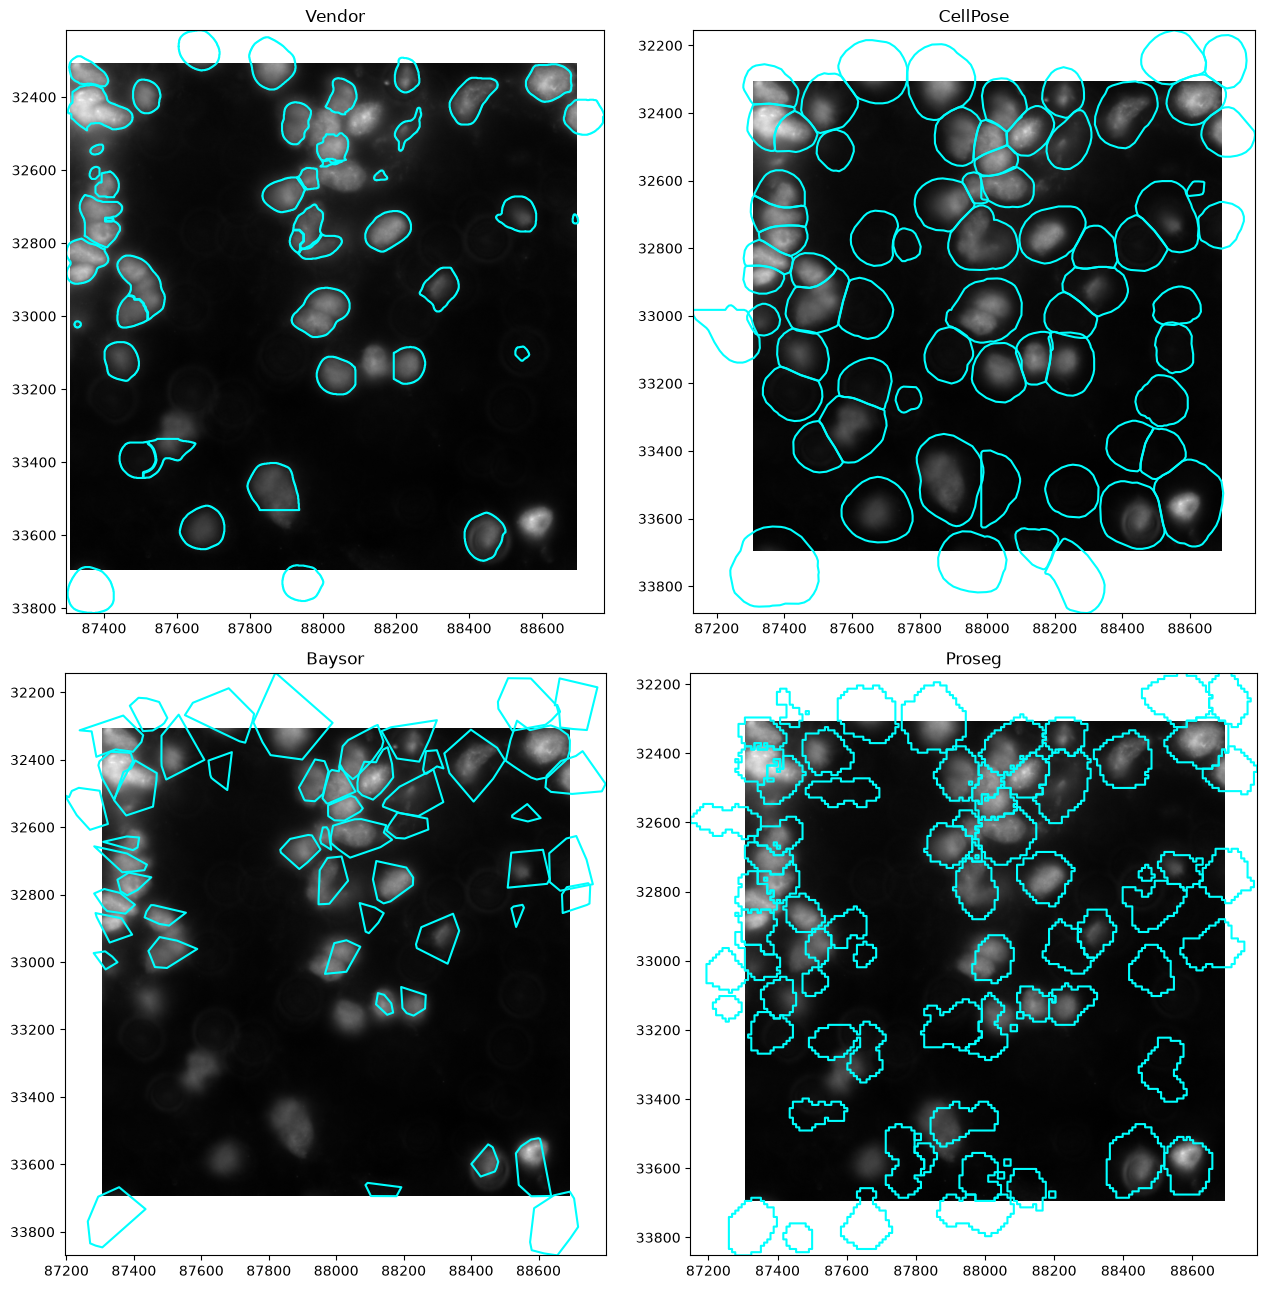

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for ax_, (label, key) in zip(axes.ravel(), METHODS.items(), strict=False):
    (
        view.pl.render_images(image_key, channel="DAPI", cmap="gray", colorbar=False)
        .pl.render_shapes(key, fill_alpha=0, outline_alpha=1, outline_color="cyan")
        .pl.show(ax=ax_, title=label)
    )
fig.tight_layout()

## 4. Assign transcripts and apply the *same* QC to every method

For each segmentation we assign transcripts to cells with the **same** Sopa aggregation, then apply the
**same** per-cell QC filter on three covariates:

- **`n_counts`** ≥ 10 transcripts · **`n_genes`** ≥ 3 distinct genes · **`area_um2`** ≥ 15 µm².

Cell **area** needs care: Cellpose polygons are in image **pixels**, the transcript methods in
**microns**, so a raw `.area` isn't comparable. The small helper below rescales every method's area to
**µm²** — defined right here so nothing is hidden.

⚠️ **A caveat on fairness.** Baysor and Proseg already enforce their *own* minimum molecules/area
*during* segmentation, so this shared filter removes very few of their cells, whereas Vendor and
Cellpose lose more. The shared filter makes the *post-hoc* criteria identical, but each method's
built-in floor still differs — keep that in mind when reading the kept-cell counts.

In [13]:
def shapes_area_um2(sdata, shapes_key, points_key):
    """Cell areas in micron^2, comparable across methods regardless of their intrinsic units."""

    def scale(key):  # element -> pixels scale (abs of the affine's x-diagonal)
        m = get_transformation(sdata[key], "global").to_affine_matrix(input_axes=("x", "y"), output_axes=("x", "y"))
        return abs(float(m[0, 0]))

    micron_per_intrinsic = scale(shapes_key) / scale(points_key)
    return sdata[shapes_key].geometry.area.to_numpy() * micron_per_intrinsic**2

In [14]:
MIN_COUNTS, MIN_GENES, MIN_AREA_UM2 = 10, 3, 15

tables = {}  # filtered cell x gene AnnData per method
assigned = {}  # transcripts each method placed in a cell, BEFORE QC (the true "fraction assigned")
report = {}
for label, shapes_key in METHODS.items():
    # (1) same aggregation for all four -> a cell x gene table
    sopa.aggregate(
        sdata,
        shapes_key=shapes_key,
        aggregate_genes=True,
        aggregate_channels=False,
        min_transcripts=0,
        key_added=f"{shapes_key}_table",
    )
    a = sdata[f"{shapes_key}_table"]
    a.layers["counts"] = a.X.copy()

    # (2) per-cell QC covariates, in the open
    X = a.X.toarray() if hasattr(a.X, "toarray") else np.asarray(a.X)
    assigned[label] = float(X.sum())
    a.obs["n_counts"] = X.sum(1)
    a.obs["n_genes"] = (X > 0).sum(1)
    area = pd.Series(shapes_area_um2(sdata, shapes_key, points_key), index=sdata[shapes_key].index.astype(str))
    a.obs["area_um2"] = area.reindex(a.obs_names.astype(str)).to_numpy()

    # (3) keep the good cells (subset the in-memory table -- all we need downstream)
    keep = (a.obs.n_counts >= MIN_COUNTS) & (a.obs.n_genes >= MIN_GENES) & (a.obs.area_um2 >= MIN_AREA_UM2)
    report[label] = {"cells (raw)": a.n_obs, "cells (kept)": int(keep.sum())}
    tables[label] = a[keep.to_numpy()].copy()

pd.DataFrame(report).T.loc[list(METHODS)]

[INFO] (sopa.aggregation.transcripts) Aggregating transcripts over 597 cells


[                                        ] | 0% Completed | 215.25 us

[                                        ] | 0% Completed | 406.62 ms

[                                        ] | 0% Completed | 510.36 ms

[########################################] | 100% Completed | 612.39 ms

...

[                                        ] | 0% Completed | 240.87 us

[                                        ] | 0% Completed | 104.30 ms

[                                        ] | 0% Completed | 209.87 ms

[########################################] | 100% Completed | 311.20 ms

,cells (raw),cells (kept)
Vendor,597,430
CellPose,897,566
Baysor,880,826
Proseg,791,629


## 5. Compare the cells — size, counts, genes, and signal captured

How do the four segmentations differ in the *cells* they produce, and how much of the measured signal
does each capture? The **fraction of transcripts assigned** uses the **pre-QC** totals (a transcript is
"assigned" if any cell caught it), so a method isn't penalised for cells that later fail QC.

🔬 **TASK 5.1 — Summarise the four segmentations.** Build a table with, per method: kept cells,
cells/mm², median transcripts and genes per cell, median area (µm²), and the **fraction of transcripts
assigned** (`prop_assigned`). 💡 **HINT:** the pre-QC totals are in `assigned`; `crop_area_mm2` is computed from `WIN_UM`;
`prop_assigned[m] = assigned[m] / n_transcripts`. Define `prop_assigned` here — the next plot reads it.

In [15]:
crop_area_mm2 = (WIN_UM / 1000) ** 2
prop_assigned = {m: assigned[m] / n_transcripts for m in METHODS}

summary = (
    pd.DataFrame(
        {
            m: {
                "n_cells": tables[m].n_obs,
                "cells / mm^2": tables[m].n_obs / crop_area_mm2,
                "median transcripts/cell": float(tables[m].obs["n_counts"].median()),
                "median genes/cell": float(tables[m].obs["n_genes"].median()),
                "median area (um^2)": float(tables[m].obs["area_um2"].median()),
                "transcripts assigned (%)": 100 * prop_assigned[m],
            }
            for m in METHODS
        }
    )
    .T.loc[list(METHODS)]
    .round(1)
)
summary

,n_cells,cells / mm^2,median transcripts/cell,median genes/cell,median area (um^2),transcripts assigned (%)
Vendor,430.0,1194.4,63.0,33.0,100.3,53.9
CellPose,566.0,1572.2,76.0,39.0,228.9,82.2
Baysor,826.0,2294.4,52.0,30.0,118.4,97.2
Proseg,629.0,1747.2,71.0,37.0,173.0,87.4


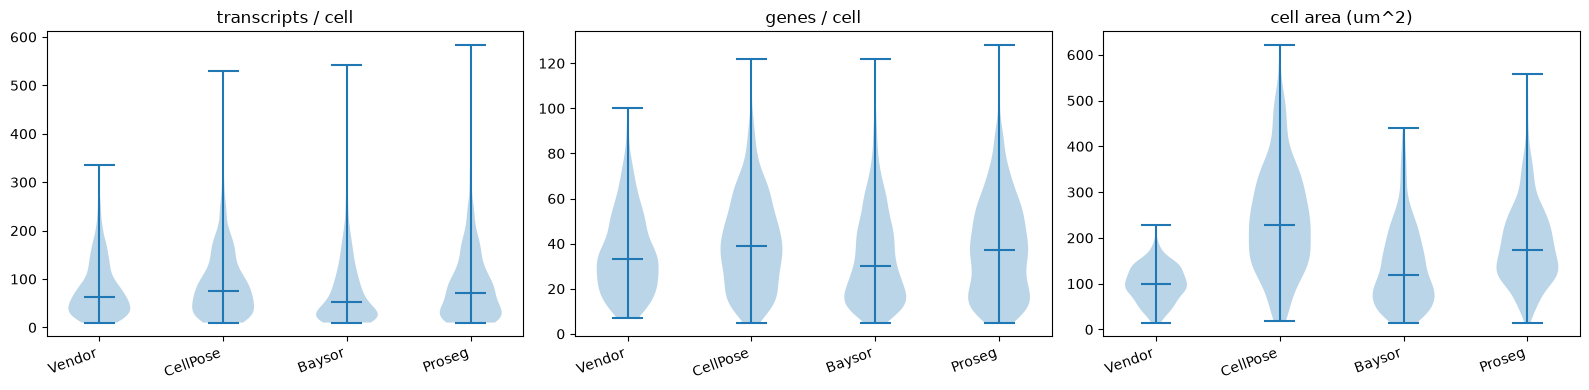

In [16]:
panels = [("transcripts / cell", "n_counts"), ("genes / cell", "n_genes"), ("cell area (um^2)", "area_um2")]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax_, (title, col) in zip(axes, panels, strict=False):
    ax_.violinplot([tables[m].obs[col].to_numpy() for m in METHODS], showmedians=True)
    ax_.set_xticks(range(1, len(METHODS) + 1))
    ax_.set_xticklabels(list(METHODS), rotation=20, ha="right")
    ax_.set(title=title)
fig.tight_layout()

**Signal captured** — the discriminating axis: the fraction of all decoded transcripts that end up
inside a cell. Same transcripts, same crop — only the segmentation differs.

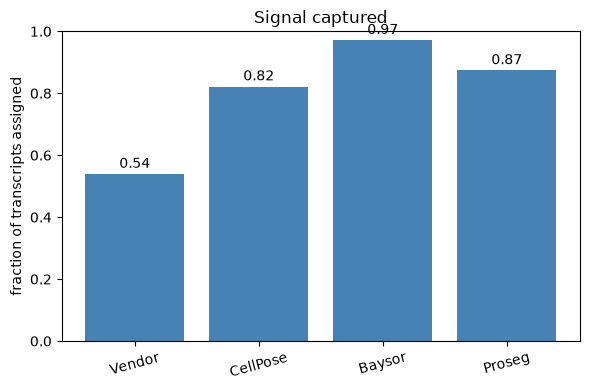

In [17]:
labels = list(METHODS)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, [prop_assigned[m] for m in labels], color="steelblue")
ax.set(ylabel="fraction of transcripts assigned", title="Signal captured", ylim=(0, 1))
ax.tick_params(axis="x", rotation=15)
for i, m in enumerate(labels):
    ax.text(i, prop_assigned[m] + 0.02, f"{prop_assigned[m]:.2f}", ha="center")
fig.tight_layout()

## 6. Are the cells *clean*? Negative-marker purity, from the ground up

More transcripts are only good if they land in the *right* cell. How do we check cleanliness with **no
cell-type labels** on the spatial side? The idea (Salas *et al.*; ResolVI): pick pairs of genes from
**mutually-exclusive cell types** — say an oligodendrocyte gene and a glutamatergic-neuron gene. A
correctly segmented cell is one type or the other, so it should almost **never** be positive for both;
when it is, transcripts leaked across a boundary. We'll build that into a score — and, along the way,
watch where its assumptions strain on *developing* tissue.

### 6.1 First, a robust "is this gene ON?" call

Everything below hinges on deciding, per cell, whether a gene is truly expressed. A plain `count > 0`
is treacherous: a **single ambient transcript** — common in both MERFISH and the reference — reads as
"detected". Instead we fit a tiny **2-component Gaussian mixture** on `log1p` counts (a background
component and a signal component) and call the higher one ON. We use this *same* call in both places —
finding exclusive pairs in the reference **and** scoring purity in space — so the two are consistent.

In [18]:
from sklearn.mixture import GaussianMixture


def gene_is_on(counts, min_positive=20):
    """Boolean 'gene is ON' per cell via a 2-component GMM on log1p counts (fallback: count > 0)."""
    c = np.asarray(counts, float).ravel()
    if (c > 0).sum() < min_positive or c.max() == 0:
        return c > 0
    x = np.log1p(c).reshape(-1, 1)
    gm = GaussianMixture(n_components=2, covariance_type="full", random_state=0, n_init=1).fit(x)
    return gm.predict(x) == int(np.argmax(gm.means_.ravel()))  # higher-mean component = signal


def counts_of(adata, g):
    x = adata[:, g].layers["counts"] if "counts" in adata.layers else adata[:, g].X
    return np.asarray(x.todense()).ravel() if hasattr(x, "todense") else np.asarray(x).ravel()

### 6.2 Mutually-exclusive markers, from *specific* reference populations

Which genes are mutually exclusive? We derive them from the independent **reference** — but with a
choice that matters in *developing* cortex. Broad classes (all "Neuron" vs all "Glia") are too
coarse: progenitors and newborn neurons blur that boundary. So we use **specific terminal cell types**
(`subclass`: glutamatergic & GABAergic neurons, oligodendrocytes, astrocytes, microglia), whose markers
are genuinely type-defining. For each population we keep genes ON in a good fraction of its cells and
almost never elsewhere. *(The per-gene GMM over the reference takes a minute or two.)*

In [19]:
ref = ad.read_h5ad(SHARED_REF)
genes = list(ref.var_names)
gidx = {g: i for i, g in enumerate(genes)}
Cref = ref.layers["counts"]
Cref = Cref.toarray() if hasattr(Cref, "toarray") else np.asarray(Cref)
labels_ref = ref.obs["subclass"].astype(str).to_numpy()

# per-cell ON/OFF for every gene in the reference (same GMM call we score with)
ON_ref = np.column_stack([gene_is_on(Cref[:, j]) for j in range(len(genes))])

POPULATIONS = ["Glutamatergic neuron", "GABAergic neuron", "Oligodendrocyte", "Astrocyte", "Microglia"]


def population_markers(n_per=8, min_frac_in=0.30, max_frac_out=0.05):
    """Genes specific to each terminal type: ON in >= min_frac_in of its cells, <= max_frac_out elsewhere."""
    out = {}
    for L in POPULATIONS:
        m = labels_ref == L
        frac_in, frac_out = ON_ref[m].mean(0), ON_ref[~m].mean(0)
        ok = (frac_in >= min_frac_in) & (frac_out <= max_frac_out)
        out[L] = [genes[i] for i in np.argsort(frac_in - frac_out)[::-1] if ok[i]][:n_per]
    return out


markers_by_pop = population_markers()
markers_by_pop

{'Glutamatergic neuron': ['SV2B', 'MLIP', 'SLIT3', 'CCBE1'],
 'GABAergic neuron': ['DLX6-AS1', 'GAD1', 'GAD2', 'NXPH2'],
 'Oligodendrocyte': ['MOBP', 'UGT8', 'BCAS1', 'ABCA8', 'SPP1'],
 'Astrocyte': ['OBI1-AS1',
  'SLCO1C1',
  'AQP4',
  'TNC',
  'GJA1',
  'EYA2',
  'FAM107A'],
 'Microglia': ['DOCK8', 'APBB1IP', 'CPED1', 'RUNX1', 'LNCAROD']}

In [20]:
# keep only cross-type pairs almost never ON together in the reference (same ON call as scoring)
def co_on_rate(ga, gb, on_matrix, ia, ib):
    ea, eb = on_matrix[:, ia], on_matrix[:, ib]
    either = (ea | eb).sum()
    return (ea & eb).sum() / either if either else 0.0


pairs = []
pops = list(markers_by_pop)
for i, la in enumerate(pops):
    for lb in pops[i + 1 :]:
        for ga in markers_by_pop[la]:
            for gb in markers_by_pop[lb]:
                if co_on_rate(ga, gb, ON_ref, gidx[ga], gidx[gb]) <= 0.02:  # <=2% co-ON
                    pairs.append((ga, gb))
pairs.sort(key=lambda p: co_on_rate(p[0], p[1], ON_ref, gidx[p[0]], gidx[p[1]]))  # most-exclusive first
print(f"{sum(len(v) for v in markers_by_pop.values())} markers -> {len(pairs)} mutually-exclusive pairs")
pairs[:8]

25 markers -> 124 mutually-exclusive pairs


[('CCBE1', 'ABCA8'),
 ('CCBE1', 'LNCAROD'),
 ('DLX6-AS1', 'LNCAROD'),
 ('DLX6-AS1', 'ABCA8'),
 ('NXPH2', 'LNCAROD'),
 ('NXPH2', 'ABCA8'),
 ('ABCA8', 'LNCAROD'),
 ('BCAS1', 'LNCAROD')]

### 6.3 *See* the exclusivity — reference, then space

Take the most mutually-exclusive pair. Plot every cell's `log1p` counts and colour **red** the cells
that are ON for **both** genes — exactly what the score will count. We show a random sample of the huge
reference so the two panels are comparable, and annotate each with its true **co-detection rate**
`P(both ON) / P(either ON)`. Compare the rates, not the raw red counts.

most mutually-exclusive pair: CCBE1 vs ABCA8


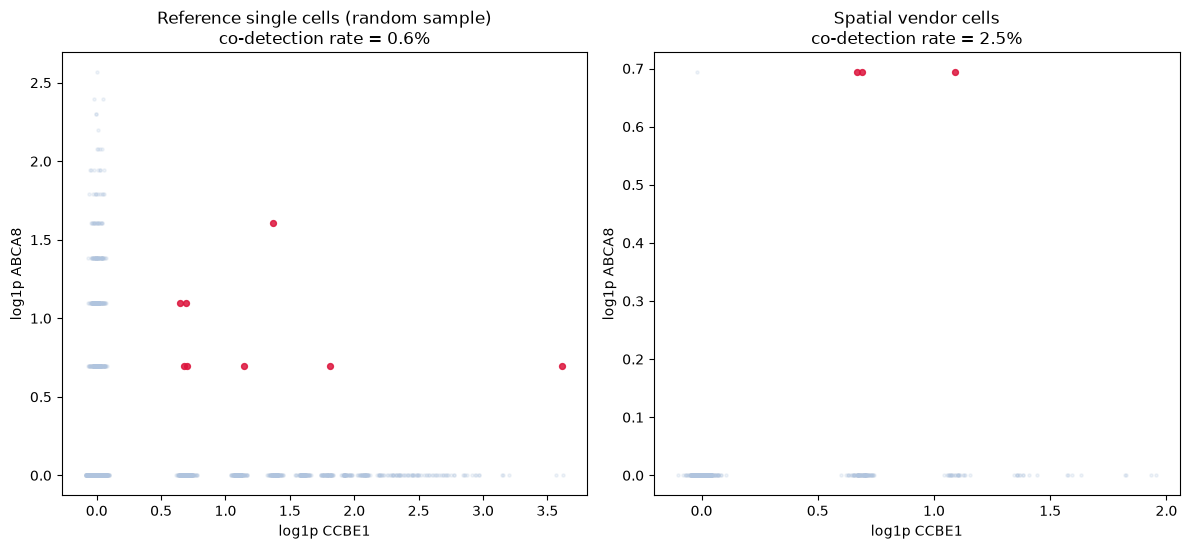

In [21]:
ga, gb = pairs[0]
print("most mutually-exclusive pair:", ga, "vs", gb)
rng = np.random.default_rng(0)


def scatter_pair(ax, ca, cb, title, n_show=3000):
    on_a, on_b = gene_is_on(ca), gene_is_on(cb)
    both = on_a & on_b
    either = (on_a | on_b).sum()
    rate = (both.sum() / either) if either else 0.0
    idx = np.arange(ca.size)
    if ca.size > n_show:
        idx = rng.choice(ca.size, n_show, replace=False)
    x, y, bo = np.log1p(ca[idx]), np.log1p(cb[idx]), both[idx]
    ax.scatter((x + rng.normal(0, 0.03, x.size))[~bo], y[~bo], s=5, alpha=0.2, color="lightsteelblue")
    ax.scatter((x + rng.normal(0, 0.03, x.size))[bo], y[bo], s=18, alpha=0.85, color="crimson")
    ax.set(title=f"{title}\nco-detection rate = {rate:.1%}", xlabel=f"log1p {ga}", ylabel=f"log1p {gb}")


vend = tables["Vendor"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
scatter_pair(axes[0], counts_of(ref, ga), counts_of(ref, gb), "Reference single cells (random sample)")
scatter_pair(axes[1], counts_of(vend, ga), counts_of(vend, gb), "Spatial vendor cells")
fig.tight_layout()

❓ **Question.** The reference co-detection rate is low (the two types really are exclusive), and
the red "ON for both" cells are rare. Is the spatial vendor rate higher or lower? A *higher* spatial
rate means some cells carry both types' transcripts — leakage across a boundary. How would a badly
**over-merging** segmentation change the corner of that cloud?

> **Answer.** The spatial vendor rate is a bit **higher** than the reference (a few more red "both ON"
> cells) — a small amount of cross-type leakage, but low overall, so these cells are mostly clean. An
> over-merging segmentation would fuse neighbouring cells of different types, driving *many* more points
> into the top-right "both ON" corner and pushing the co-detection rate up — which is exactly what the
> purity score below turns into a single number, averaged over all pairs.

### 6.4 Turn it into a score

**Negative-marker purity** = `1 − (mean cross-type co-detection rate)` over all pairs — using the same
`gene_is_on` call. Higher = cleaner. A few lines, defined here so nothing is a black box.

In [22]:
def negative_marker_purity(adata, pairs):
    """1 - mean cross-type double-positive rate over `pairs` (higher = cleaner)."""
    present = {g for pair in pairs for g in pair if g in adata.var_names}
    on = {g: gene_is_on(counts_of(adata, g)) for g in present}
    rates = []
    for ga, gb in pairs:
        if ga in on and gb in on:
            either = (on[ga] | on[gb]).sum()
            if either:
                rates.append((on[ga] & on[gb]).sum() / either)
    return 1.0 - float(np.mean(rates)) if rates else float("nan")

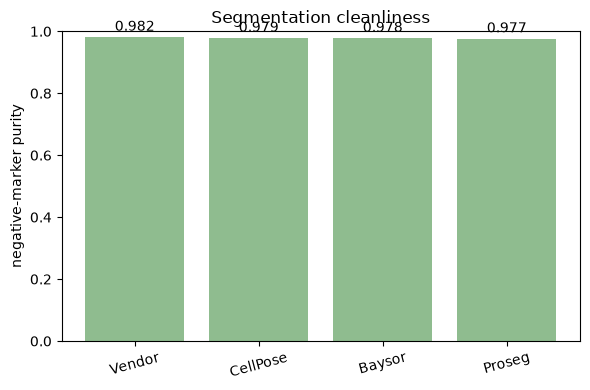

In [23]:
purity = {m: negative_marker_purity(tables[m], pairs) for m in METHODS}

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, [purity[m] for m in labels], color="darkseagreen")
ax.set(ylabel="negative-marker purity", title="Segmentation cleanliness", ylim=(0, 1))
ax.tick_params(axis="x", rotation=15)
for i, m in enumerate(labels):
    ax.text(i, purity[m] + 0.02, f"{purity[m]:.3f}", ha="center")
fig.tight_layout()

❓ **What do you notice?** How does purity compare across the four methods — does it *rank* them,
or is it flat? Use the §3 overlays and the §6.3 scatter to explain why.

> **Answer.** Purity is high **and essentially flat** across all four methods — it barely separates
> them. The §3 overlays show why: the cells here are well-isolated, so *any* reasonable segmentation is
> clean and there's little cross-type leakage to detect (low co-detection in §6.3). Purity is a **guard
> rail** — it would catch a badly over-merging segmentation — not the axis that ranks methods on this
> tissue. The axis that *does* separate them is the **signal captured** in §5.

### 6.5 A caveat worth teaching — "mutually exclusive" is only *approximate* here

Look again at §6.3: even in the **reference**, a few cells are ON for both markers. The assumption behind
this whole metric — "one cell = one lineage, so these genes never co-occur" — is an **adult-tissue**
idealisation (where Salas *et al.* validated it). It is softer in second-trimester cortex.

❓ **Question.** Give three reasons a cell might be a genuine "double-positive" in the reference
even though we picked the *most* mutually-exclusive pair. (Hint: one technical, one about the markers,
one about the biology of a *developing* brain.)

> **Answer.** (1) **Technical** — the GMM removes most ambient, but not all; a few background
> transcripts still tip a cell ON, and dissociated multiome has its own doublets. (2) **Markers** — no
> gene is perfectly specific; a marker ON in 30% of its type is still occasionally ON elsewhere, so some
> pairs co-occur by imperfect specificity. (3) **Biology** — developing cortex is a **continuum**:
> radial glia, intermediate progenitors and newborn neurons are mid-transition and genuinely co-express
> markers of more than one *mature* type. So purity is a coarse guard rail, trustworthy for catching
> gross over-merging, not for finely ranking already-clean segmentations — and worth *more* scrutiny in
> developing tissue than in the adult brain the metric was built for.

🚀 **Going further (optional — open-ended).**
- **Which type-pair breaks each method?** Split purity *by pair* and recompute per method. Does a method
  fail on a particular morphology (large astrocytes vs small interneurons)?
- **Is the metric stable across the crop?** Tile the crop, recompute per tile per method, and map it.

## 7. What do the extra transcripts buy us? Compare by eye.

More assigned transcripts mean more counts per cell — but do they translate into cleaner cell-type
structure? Build a UMAP from **each** method's counts and colour it by a few canonical lineage markers,
then judge for yourself.

❓ **QUESTION.** Which method gives the most clearly separated lineages — and is it the one that captured
the *most* transcripts? Does more signal always mean better-resolved structure?

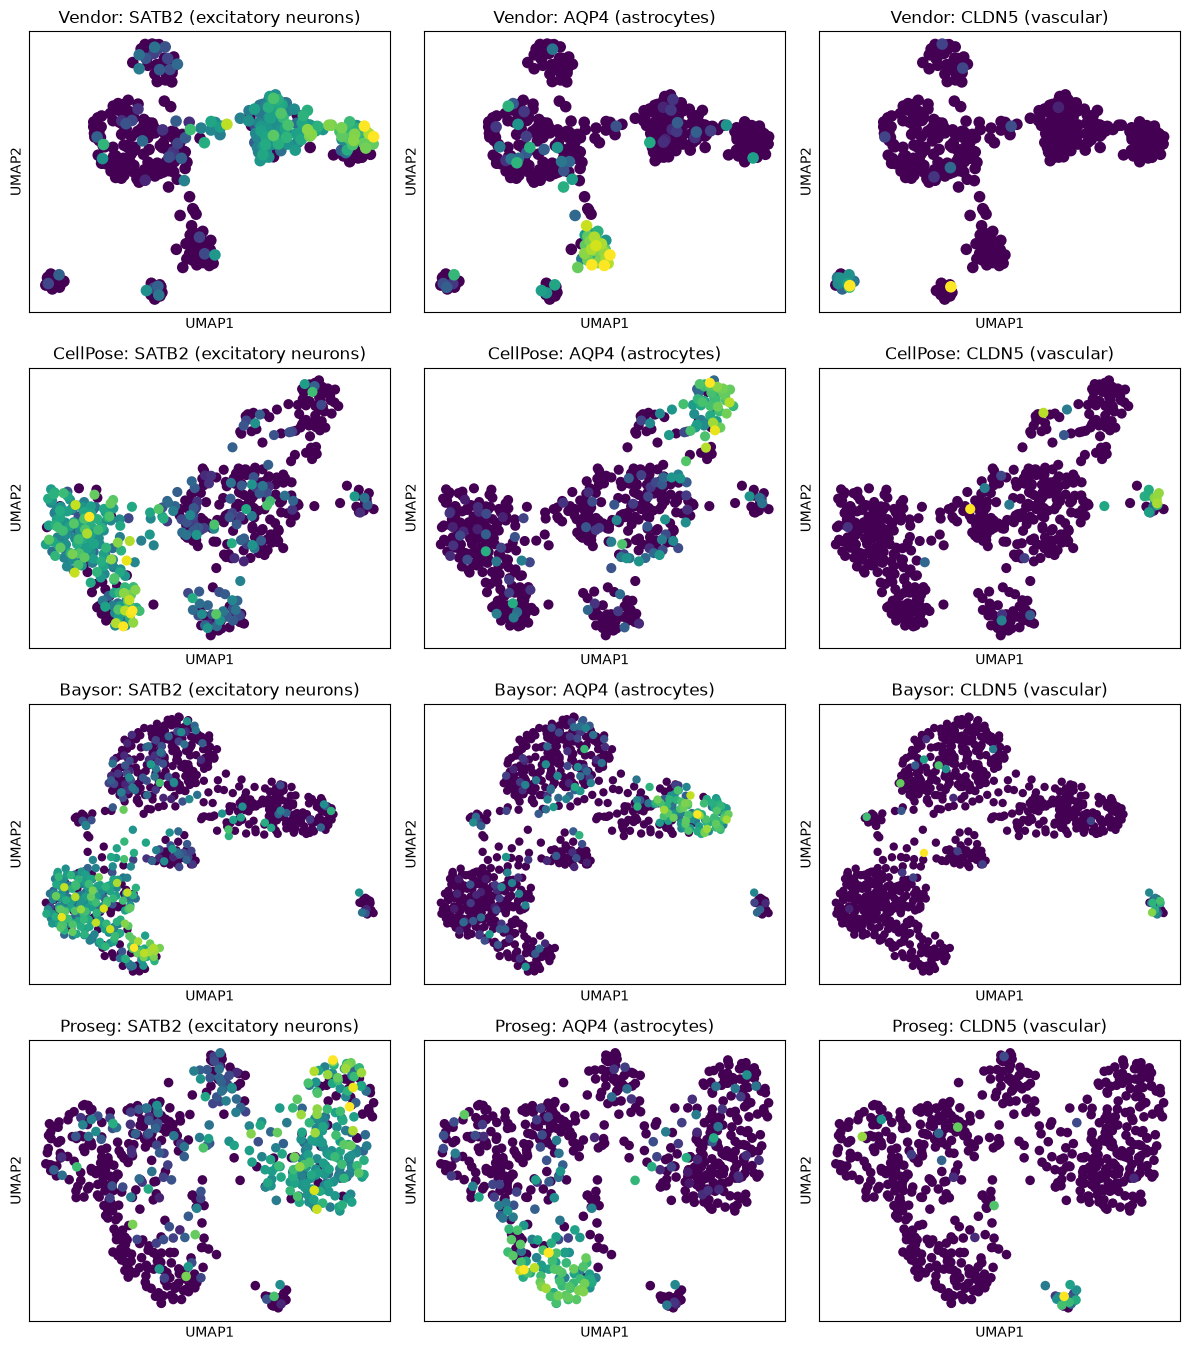

In [24]:
lineage_of = {"SATB2": "excitatory neurons", "AQP4": "astrocytes", "CLDN5": "vascular"}
marker_genes = [g for g in lineage_of if g in tables["Proseg"].var_names]

embeds = {}
for m in METHODS:
    a = tables[m].copy()
    a.X = a.layers["counts"].copy()
    sc.pp.normalize_total(a)
    sc.pp.log1p(a)
    sc.pp.pca(a, n_comps=30)
    sc.pp.neighbors(a)
    sc.tl.umap(a)
    embeds[m] = a

fig, axes = plt.subplots(len(METHODS), len(marker_genes), figsize=(4 * len(marker_genes), 3.4 * len(METHODS)))
for i, m in enumerate(METHODS):
    for j, g in enumerate(marker_genes):
        sc.pl.umap(
            embeds[m], color=g, ax=axes[i, j], show=False, colorbar_loc=None, title=f"{m}: {g} ({lineage_of[g]})"
        )
fig.tight_layout()

## 8. Conclusion

- **Signal captured** separates the methods: on this crop the **Vendor** segmentation assigns the
  fewest transcripts and all three re-segmentations capture more — **Baysor** the most, then **Proseg**,
  then **CellPose** (still a clear gain over the vendor).
- But *where* those transcripts go differs (see §5 violins): capturing more total signal can mean
  smaller or more numerous cells — there is no free lunch.
- **Purity** is high and flat everywhere — on this well-separated tissue it confirms all segmentations
  are clean but doesn't rank them. It's a **guard rail**, and you built it from the reference up.
- The **UMAPs** let you compare structure across methods directly.

There is no single "correct" segmentation — the right choice trades off total signal, cell count, cell
size, and runtime. The point is to *measure* the trade-off rather than trust the vendor default blindly.

**Further reading.** Sopa ([docs](https://gustaveroussy.github.io/sopa/), Blampey *et al.*, *Nat.
Commun.* 2024) · the purity metric: Salas *et al.* (*Nat. Methods* 2025,
[10.1038/s41592-025-02617-2](https://doi.org/10.1038/s41592-025-02617-2)) and **ResolVI** (Ergen &
Yosef, bioRxiv 2025) · the Cellpose, Baysor, and Proseg papers for the methods themselves.